# Urban Mobility & Economic Productivity in Latin America

**Author:** Carlos Alberto Celis Martínez

## Context
As a data analyst, the goal of this project is to evaluate how urban mobility (traffic congestion, delays, travel times) relates to economic productivity (GDP per capita) across major Latin American cities. The analysis combines two real-world data sources — the TomTom Traffic Index and OECD Cities economic data — to identify which cities would benefit most from investment in transport infrastructure.

**Business questions:**
- Which cities show high congestion combined with low economic productivity?
- Which cities show the best combined indicators (efficient mobility + strong economy)?
- Which variables appear most strongly related to urban development?

## 1. Load and Explore the Data

Import the required libraries and load both datasets to get a first look at their structure.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load files
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:
# show first 5 rows of traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# show first 5 rows of eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


## 2. Explore Structure and Data Types

Before cleaning, inspect each dataset's structure, column types, and missing values.

In [5]:
# examine the structure of traffic
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


In [6]:
traffic.shape

(1004464, 12)

**Observations on the `traffic` dataset:**

- The `UpdateTimeUTC` columns are stored as text (object) rather than datetime.
- `City` and `Country` are correctly formatted as text; all other columns are float64, which is appropriate.
- No missing values were found.

In [7]:
# examine the structure of eco
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


In [8]:
eco.shape

(30, 7)

**Observations on the `eco` dataset:**

- The columns `City GDP/capita`, `Unemployment %`, `PM2.5 (µg/m³)`, and `Population (M)` are stored as text (object) instead of float64.
- No missing values were found.

## 3. Standardize Column Names

Rename columns to `snake_case` for consistency and to simplify merging the datasets later.

In [9]:
# standardize traffic column names
traffic.columns= ['country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live',
       'jams_length_in_kms', 'jams_count', 'traffic_index_week_ago',
       'update_time_utc_week_ago', 'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay']
# verify changes
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [10]:
# standardize eco column names
eco.columns = eco.columns.str.lower().str.replace(' ', '_').str.replace('/', '_').str.replace('%', 'pct').str.replace('(', '').str.replace(')', '').str.strip()
# verify changes
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm2.5_μg_m³', 'population_m'],
      dtype='object')

## 4. Fix Numeric and Date Formats

Convert date columns to `datetime`, and clean numeric columns in the `eco` dataset (removing thousands separators, percent signs, and standardizing decimal commas to periods).

In [11]:
# convert traffic date columns using pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'],errors="coerce", utc=True)
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'],errors="coerce", utc=True)

# verify the change
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype              
---  ------                               --------------    -----              
 0   country                              1004464 non-null  object             
 1   city                                 1004464 non-null  object             
 2   update_time_utc                      1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                           1004464 non-null  float64            
 4   traffic_index_live                   1004464 non-null  float64            
 5   jams_length_in_kms                   1004464 non-null  float64            
 6   jams_count                           1004464 non-null  float64            
 7   traffic_index_week_ago               1004464 non-null  float64            
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns, UTC]
 9   tr

In [12]:
# clean separators and convert numeric columns in eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# calculate total population in absolute units (multiply * 1,000,000)
eco['population'] = eco['population_m']* 1000000

# verify the change
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm2.5_μg_m³       30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_μg_m³,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


## 5. Extract Year and Filter to 2024

Create a `year` column from the traffic timestamps and keep only records from 2024, working on explicit copies to avoid modifying the original data.

In [13]:
# extract the year from update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# verify change
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [14]:
# filter records for year 2024
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year']==2024].copy()

# review new dataframes
display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_μg_m³,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


## 6. Aggregate Traffic Metrics by City

The traffic dataset contains multiple records per city. Averaging key metrics by city and year gives a clearer view of overall trends.

In [15]:
# calculate traffic averages by city, country, and year
traffic_city_year_2024 =  traffic_2024.groupby(['city','country','year'])[['jams_delay', 'traffic_index_live', 'jams_length_in_kms', 'jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins']].mean().reset_index()

# show result
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [16]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


**Finding:** Mexico City has the highest average traffic delay of all cities analyzed.

## 7. Merge Mobility and Economic Data

Select the relevant columns from each dataset and merge them on `city` and `year` using an inner join, keeping only cities and years present in both sources.

In [17]:
# select key traffic and economy columns
left_cols = ['city','country','year','jams_delay','traffic_index_live','jams_count','mins_delay']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','population']

# use .copy() to create the two reduced datasets
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# merge datasets
merged = pd.merge(traffic_2024_small,eco_2024_small, on=['city', 'year'], how='inner')

# show first 5 rows
merged = merged.rename(columns={'mins_delay':'mins_delay_per_10kms'})
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_count,mins_delay_per_10kms,city_gdp_capita,unemployment_pct,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,68.805422,0.487228,11124.0,9.5,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,230.566550,1.699628,11442.0,10.0,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,27.280140,0.193442,16251.0,7.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,137.359860,0.416566,18117.0,7.2,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,46.898164,0.139965,12381.0,8.2,3700000.0


## 8. Visualize Relationships

With a clean, unified dataset, the next step is to visualize patterns between traffic congestion and economic indicators.

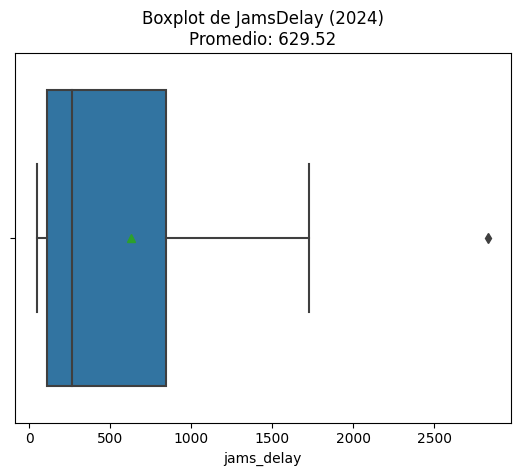

In [18]:
# create boxplot to observe jams_delay (congestion minutes) behavior
sns.boxplot(data=merged, x='jams_delay', showmeans=True)

# get the mean to display in the title
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot of JamsDelay (2024)\nMean: {mean_value:.2f}')
plt.show()

In [19]:
# review outlier / added by analyst
merged[merged['jams_delay'] > 2000]

,city,country,year,jams_delay,traffic_index_live,jams_count,mins_delay_per_10kms,city_gdp_capita,unemployment_pct,population
7,mexico-city,MEX,2024,2833.057892,34.21819,594.969392,1.855542,21111.0,3.2,22100000.0


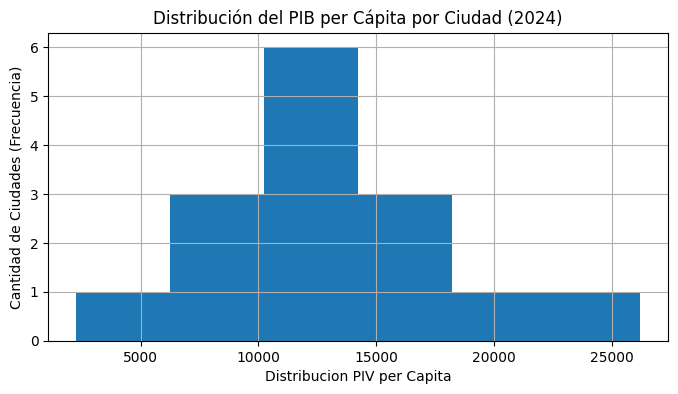

In [20]:
# create histogram to view the distribution of GDP per capita
merged['city_gdp_capita'].hist(bins=6, figsize=(8,4))
plt.title('GDP per Capita Distribution by City (2024)')
plt.xlabel('GDP per Capita')
plt.ylabel('Number of Cities (Frequency)')
plt.show()

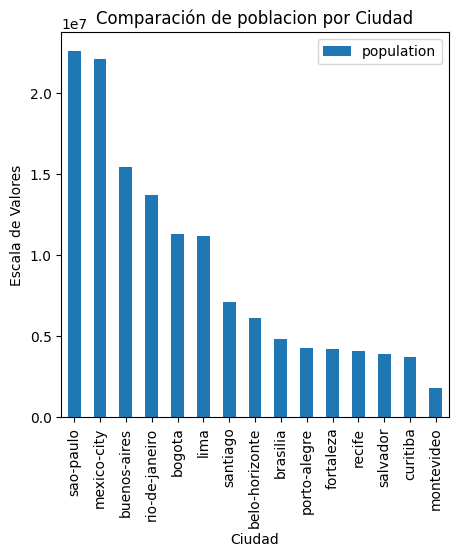

In [21]:
merged_population = merged.sort_values(by='population', ascending=False)
merged_population.plot(kind='bar', figsize=(5, 5), x='city', y='population')

plt.title('Population Comparison by City')
plt.xlabel('City')
plt.ylabel('Value Scale')
plt.xticks(rotation=90)
plt.show()

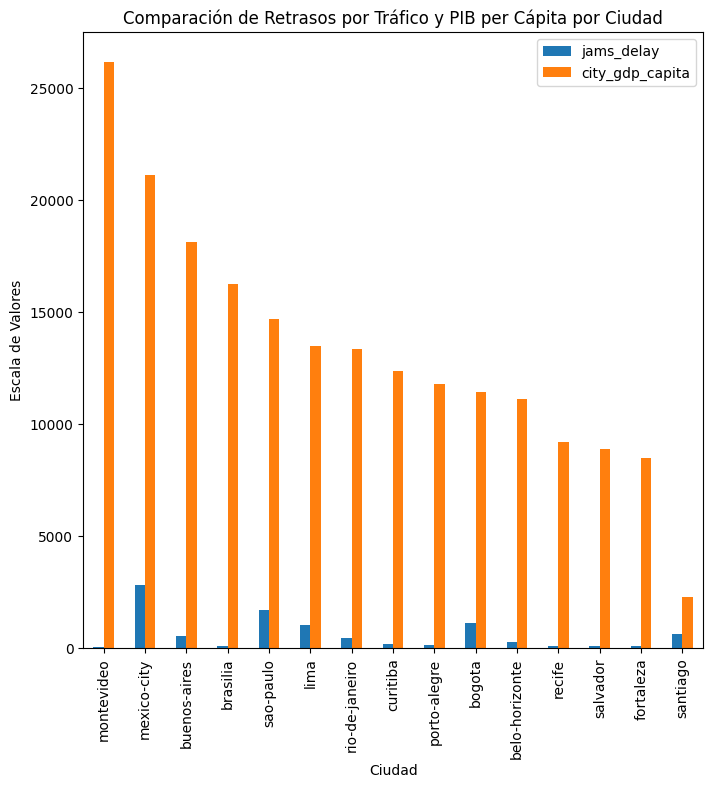

In [22]:
# bar chart to compare jams_delay and city_gdp_capita by city
merged_ordenado = merged.sort_values(by='city_gdp_capita', ascending=False)
merged_ordenado.plot(kind='bar', figsize=(8, 8), x='city', y=['jams_delay', 'city_gdp_capita'])

plt.title('Traffic Delay vs. GDP per Capita by City')
plt.xlabel('City')
plt.ylabel('Value Scale')
plt.xticks(rotation=90)
plt.show()

**Findings:** Cities with a higher GDP per capita do not necessarily show higher traffic congestion. Montevideo, the city with the highest GDP per capita, has one of the lowest congestion levels. Mexico City, in contrast, shows the highest congestion despite having the second-highest GDP. This pattern varies across the dataset without a clear direct relationship between the two metrics. Population size, however, does show a more consistent relationship with congestion — more populous cities tend to have higher congestion levels.

## 9. Export Final Dataset

Save the cleaned, merged dataset for further use.

In [23]:
# export the final dataset as CSV
merged_ordenado.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

## Executive Summary

### Objective
This analysis examines the relationship between urban mobility and GDP per capita across major Latin American cities, in order to identify where investment in transport infrastructure could have the greatest economic impact. It draws on the TomTom Traffic Index for urban mobility and OECD Cities data for GDP per capita, unemployment, and population, covering 15 cities across 7 Latin American countries in 2024.

### Methodology
Data was cleaned and standardized (lowercase snake_case column names, removal of noisy characters via string operations), filtered to 2024 using explicit in-memory copies to avoid conflicts, then aggregated by city-year averages for key traffic metrics. An inner join integrated congestion indicators with economic variables. Results were validated visually using a histogram (GDP distribution), a boxplot (outlier detection and mean/median comparison), a bar chart (population comparison), and a sorted bar chart contrasting economic strength against traffic congestion across cities.

### Key Findings
Cities with higher GDP per capita do not directly correlate with higher traffic congestion. Montevideo, the city with the highest GDP per capita, has exceptionally low congestion. Mexico City shows the highest congestion among the 15 cities despite ranking second in GDP per capita.

Results vary considerably across cities: while lower-GDP cities generally show lower congestion, exceptions like Santiago de Chile and Bogotá — which combine high congestion with lower GDP — show this isn't a strict rule. Population size shows a more consistent relationship with congestion: more populated metro areas tend to show higher congestion levels.

*Note: Mexico City shows an outlier delay value of 2833.05, which may reflect a data collection issue and merits further validation.*

### Recommendations

**Invest in road infrastructure in Bogotá and Santiago de Chile.** Both cities show relatively low GDP despite being highly populated metro areas; targeted infrastructure investment could unlock productivity gains tied to improved mobility.

**Study Buenos Aires as a benchmark.** Despite its large population, it shows a strong GDP per capita while maintaining moderate congestion levels compared to similarly sized cities — worth analyzing what's driving that balance.

**Validate the Mexico City outlier.** Confirm the accuracy of this data point before using it in further analysis, to avoid bias from a potential collection error.